# 04 - Modeling

This notebook trains, evaluates, and compares baseline and behavior-aware machine learning models for customer behavior shift detection.

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, accuracy_score)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from pathlib import Path
import os


In [2]:
# Load the modeling dataset
file_path = "../data/processed/behavior_change_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Dataset shape: (19651, 32)
Columns:
['Customer ID', 'Month', 'transaction_count', 'total_quantity', 'total_spending', 'average_transaction_value', 'unique_products', 'previous_month', 'months_since_previous', 'previous_transaction_count', 'previous_total_quantity', 'previous_total_spending', 'previous_average_transaction_value', 'previous_unique_products', 'change_transaction_count', 'change_total_quantity', 'change_total_spending', 'change_average_transaction_value', 'change_unique_products', 'pct_change_transaction_count', 'pct_change_total_quantity', 'pct_change_total_spending', 'pct_change_average_transaction_value', 'pct_change_unique_products', 'large_change_count', 'behavior_shift_candidate', 'core_large_change_count', 'core_behavior_shift_candidate', 'behavior_shift', 'historical_active_months', 'historical_transactions', 'historical_spending']


,Customer ID,Month,transaction_count,total_quantity,total_spending,average_transaction_value,unique_products,previous_month,months_since_previous,previous_transaction_count,...,pct_change_average_transaction_value,pct_change_unique_products,large_change_count,behavior_shift_candidate,core_large_change_count,core_behavior_shift_candidate,behavior_shift,historical_active_months,historical_transactions,historical_spending
0,12346.0,2010-06,1,19,142.31,7.490000,19,2010-03,3,1.0,...,3.844732e+01,280.000000,3,True,3,True,1,0,1.0,27.05
1,12346.0,2011-01,1,74215,77183.60,77183.600000,1,2010-06,7,1.0,...,1.030389e+06,-94.736842,3,True,3,True,1,1,2.0,169.36
2,12347.0,2010-12,1,319,711.79,22.960968,31,2010-10,2,1.0,...,5.018702e+01,-22.500000,0,False,0,False,0,0,1.0,611.53
3,12347.0,2011-01,1,315,475.39,16.392759,29,2010-12,1,1.0,...,-2.860598e+01,-6.451613,0,False,0,False,0,1,2.0,1323.32
4,12347.0,2011-04,1,483,636.25,26.510417,24,2011-01,3,1.0,...,6.172029e+01,-17.241379,0,False,0,False,0,2,3.0,1798.71


In [3]:
# Define target
target_column = "behavior_shift"

# Baseline features
baseline_features = [
    "historical_active_months",
    "historical_transactions",
    "historical_spending"
]

# Behavior-aware features
behavior_aware_features = [
    "historical_active_months",
    "historical_transactions",
    "historical_spending",
    "previous_transaction_count",
    "previous_total_quantity",
    "previous_total_spending",
    "previous_average_transaction_value",
    "previous_unique_products",
    "months_since_previous"
]

print("Target:", target_column)

print("\nBaseline features:")
print(baseline_features)

print("\nBehavior-aware features:")
print(behavior_aware_features)

Target: behavior_shift

Baseline features:
['historical_active_months', 'historical_transactions', 'historical_spending']

Behavior-aware features:
['historical_active_months', 'historical_transactions', 'historical_spending', 'previous_transaction_count', 'previous_total_quantity', 'previous_total_spending', 'previous_average_transaction_value', 'previous_unique_products', 'months_since_previous']


In [4]:
# Define time-based split boundaries

train_end = "2011-05"
validation_end = "2011-08"

# Training set
train_df = df[
    df["Month"] <= train_end
].copy()

# Validation set
validation_df = df[
    (df["Month"] > train_end) &
    (df["Month"] <= validation_end)
].copy()

# Test set
test_df = df[
    df["Month"] > validation_end
].copy()

print("Train period:",
      train_df["Month"].min(), "to", train_df["Month"].max())

print("Validation period:",
      validation_df["Month"].min(), "to", validation_df["Month"].max())

print("Test period:",
      test_df["Month"].min(), "to", test_df["Month"].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train period: 2010-01 to 2011-05
Validation period: 2011-06 to 2011-08
Test period: 2011-09 to 2011-12

Rows:
Train: 12832
Validation: 2553
Test: 4266


In [5]:
# Check target distribution across all data splits

for name, dataset in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    print(f"\n{name} target distribution:")
    
    print(dataset[target_column].value_counts().sort_index())
    
    print("\nPercentage:")
    print(
        dataset[target_column]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )


Train target distribution:
behavior_shift
0    10745
1     2087
Name: count, dtype: int64

Percentage:
behavior_shift
0    83.74
1    16.26
Name: proportion, dtype: float64

Validation target distribution:
behavior_shift
0    2198
1     355
Name: count, dtype: int64

Percentage:
behavior_shift
0    86.09
1    13.91
Name: proportion, dtype: float64

Test target distribution:
behavior_shift
0    3471
1     795
Name: count, dtype: int64

Percentage:
behavior_shift
0    81.36
1    18.64
Name: proportion, dtype: float64


In [6]:
# Prepare baseline features and target

X_train_baseline = train_df[baseline_features].copy()
X_validation_baseline = validation_df[baseline_features].copy()
X_test_baseline = test_df[baseline_features].copy()

y_train = train_df[target_column].copy()
y_validation = validation_df[target_column].copy()
y_test = test_df[target_column].copy()

print("Baseline training shape:", X_train_baseline.shape)
print("Baseline validation shape:", X_validation_baseline.shape)
print("Baseline test shape:", X_test_baseline.shape)

print("\nTarget shapes:")
print("Train:", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:", y_test.shape)

Baseline training shape: (12832, 3)
Baseline validation shape: (2553, 3)
Baseline test shape: (4266, 3)

Target shapes:
Train: (12832,)
Validation: (2553,)
Test: (4266,)


In [7]:
# Define baseline preprocessing

baseline_log_features = [
    "historical_transactions",
    "historical_spending"
]

baseline_numeric_features = [
    "historical_active_months"
]

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "log",
            Pipeline([
                ("log1p", FunctionTransformer(np.log1p)),
                ("scaler", StandardScaler())
            ]),
            baseline_log_features
        ),
        (
            "numeric",
            StandardScaler(),
            baseline_numeric_features
        )
    ]
)

print("Baseline preprocessing pipeline created.")

Baseline preprocessing pipeline created.


In [8]:
# Build the baseline Logistic Regression pipeline

baseline_model = Pipeline([
    ("preprocessing", baseline_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

print("Baseline Logistic Regression pipeline created.")

Baseline Logistic Regression pipeline created.


In [9]:
# Fit the baseline model on the training data

baseline_model.fit(
    X_train_baseline,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [10]:
# Generate predictions on the validation set

y_validation_pred = baseline_model.predict(
    X_validation_baseline
)

y_validation_proba = baseline_model.predict_proba(
    X_validation_baseline
)[:, 1]

print("Validation predictions generated.")
print("Predictions shape:", y_validation_pred.shape)
print("Probabilities shape:", y_validation_proba.shape)

Validation predictions generated.
Predictions shape: (2553,)
Probabilities shape: (2553,)


In [11]:
baseline_validation_metrics = {
    "Precision": precision_score(y_validation, y_validation_pred),
    "Recall": recall_score(y_validation, y_validation_pred),
    "F1": f1_score(y_validation, y_validation_pred),
    "ROC-AUC": roc_auc_score(y_validation, y_validation_proba),
    "PR-AUC": average_precision_score(
        y_validation,
        y_validation_proba
    )
}

print("Baseline Validation Metrics:")
for metric, value in baseline_validation_metrics.items():
    print(f"{metric}: {value:.4f}")

Baseline Validation Metrics:
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
ROC-AUC: 0.5763
PR-AUC: 0.1804


## Baseline Validation Probability Analysis

The predicted probabilities are inspected to understand how the baseline model
separates the two target classes.

We compare the probability distribution overall and the average predicted
probability for each actual class.

In [12]:
# Inspect the distribution of predicted probabilities and compare them by actual class

print("Validation probability summary:")

print(pd.Series(y_validation_proba).describe())

print("\nMean probability by actual class:")

print(
    pd.DataFrame({
        "target": y_validation.values,
        "probability": y_validation_proba
    })
    .groupby("target")["probability"]
    .agg(["count", "mean", "median", "min", "max"])
)

Validation probability summary:
count    2553.000000
mean        0.182089
std         0.054922
min         0.040110
25%         0.144876
50%         0.175919
75%         0.213064
max         0.572563
dtype: float64

Mean probability by actual class:
        count      mean    median       min       max
target                                               
0        2198  0.180073  0.174376  0.040110  0.572563
1         355  0.194573  0.194415  0.053993  0.456900


## Baseline Threshold Analysis

The default classification threshold of 0.5 produces no positive predictions,
resulting in zero recall and F1-score.

Since the predicted probabilities show some separation between the two classes,
we evaluate alternative decision thresholds on the validation set.

The threshold will be selected using the F1-score on the validation data and
then kept fixed for the final test evaluation.

In [13]:
# Evaluate baseline performance across different classification thresholds

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    y_validation_pred_threshold = (
        y_validation_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            y_validation_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            y_validation_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            y_validation_pred_threshold,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,threshold,precision,recall,f1
0,0.10,0.140708,0.974648,0.245913
1,0.15,0.151432,0.774648,0.253339
2,0.20,0.188746,0.453521,0.266556
3,0.25,0.212000,0.149296,0.175207
4,0.30,0.225352,0.045070,0.075117
5,0.35,0.320000,0.022535,0.042105
6,0.40,0.166667,0.002817,0.005540
7,0.45,0.200000,0.002817,0.005556
8,0.50,0.000000,0.000000,0.000000


### Select the Best Validation Threshold

The threshold that achieves the highest F1-score on the validation set is selected
for the final baseline evaluation.

In [14]:
# Select the threshold with the highest validation F1-score

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

print("Best threshold:", best_threshold)
print("Precision:", round(best_threshold_row["precision"], 4))
print("Recall:", round(best_threshold_row["recall"], 4))
print("F1:", round(best_threshold_row["f1"], 4))

Best threshold: 0.20000000000000004
Precision: 0.1887
Recall: 0.4535
F1: 0.2666


## Final Baseline Validation Evaluation

The threshold selected using validation F1-score is applied to generate
the final baseline validation predictions.

This threshold will be kept fixed when evaluating the baseline model
on the test set.

In [15]:
# Apply the selected threshold to generate final baseline validation predictions

baseline_validation_threshold = best_threshold

y_validation_pred_baseline = (
    y_validation_proba >= baseline_validation_threshold
).astype(int)

print("Baseline validation threshold:", baseline_validation_threshold)
print("Positive predictions:", y_validation_pred_baseline.sum())
print("Total validation observations:", len(y_validation_pred_baseline))

Baseline validation threshold: 0.20000000000000004
Positive predictions: 853
Total validation observations: 2553


## Baseline Confusion Matrix

The confusion matrix shows how the baseline model's validation predictions
compare with the actual behavior-shift labels at the selected threshold.

In [16]:
# Evaluate baseline validation predictions using a confusion matrix


baseline_cm = confusion_matrix(
    y_validation,
    y_validation_pred_baseline
)

print("Baseline Validation Confusion Matrix:")
print(baseline_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_validation_pred_baseline,
        target_names=["No Shift", "Behavior Shift"],
        zero_division=0
    )
)

Baseline Validation Confusion Matrix:
[[1506  692]
 [ 194  161]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.89      0.69      0.77      2198
Behavior Shift       0.19      0.45      0.27       355

      accuracy                           0.65      2553
     macro avg       0.54      0.57      0.52      2553
  weighted avg       0.79      0.65      0.70      2553



## Baseline Validation Results

Using the threshold selected from validation F1-score (0.20), the baseline
Logistic Regression achieved a recall of 0.45 and an F1-score of 0.27
for the Behavior Shift class.

The model correctly identified 161 of 355 behavior-shift observations,
while producing 692 false positives.

These results provide the baseline against which the behavior-aware model
will be compared.

## Behavior-Aware Model

The behavior-aware model extends the baseline feature set with recent
customer behavioral information from the previous active month.

The objective is to determine whether incorporating recent behavioral
features improves behavior shift detection compared with the baseline model.

In [17]:
# Prepare behavior-aware features and target

X_train_behavior = train_df[behavior_aware_features].copy()
X_validation_behavior = validation_df[behavior_aware_features].copy()
X_test_behavior = test_df[behavior_aware_features].copy()

print("Behavior-aware training shape:", X_train_behavior.shape)
print("Behavior-aware validation shape:", X_validation_behavior.shape)
print("Behavior-aware test shape:", X_test_behavior.shape)

print("\nTarget shapes:")
print("Train:", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:", y_test.shape)

Behavior-aware training shape: (12832, 9)
Behavior-aware validation shape: (2553, 9)
Behavior-aware test shape: (4266, 9)

Target shapes:
Train: (12832,)
Validation: (2553,)
Test: (4266,)


### Behavior-Aware Preprocessing

Highly right-skewed behavioral features are log-transformed using log1p
before standardization.

The preprocessing is fitted only on the training data through the pipeline
to avoid data leakage.

In [18]:
# Define behavior-aware preprocessing

behavior_aware_log_features = [
    "historical_transactions",
    "historical_spending",
    "previous_transaction_count",
    "previous_total_quantity",
    "previous_total_spending",
    "previous_average_transaction_value",
    "previous_unique_products"
]

behavior_aware_numeric_features = [
    "historical_active_months",
    "months_since_previous"
]

behavior_aware_preprocessor = ColumnTransformer(
    transformers=[
        (
            "log",
            Pipeline([
                ("log1p", FunctionTransformer(np.log1p)),
                ("scaler", StandardScaler())
            ]),
            behavior_aware_log_features
        ),
        (
            "numeric",
            StandardScaler(),
            behavior_aware_numeric_features
        )
    ]
)

print("Behavior-aware preprocessing pipeline created.")

Behavior-aware preprocessing pipeline created.


### Behavior-Aware Logistic Regression

A Logistic Regression classifier is used to provide a direct comparison
with the baseline model.

The same model family is intentionally used so that any performance
difference can be attributed primarily to the additional behavioral features.

In [19]:
# Create the behavior-aware Logistic Regression pipeline

behavior_aware_model = Pipeline([
    ("preprocessor", behavior_aware_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Behavior-aware Logistic Regression pipeline created.")

Behavior-aware Logistic Regression pipeline created.


### Generate Behavior-Aware Validation Predictions

Generate validation-set predictions and probabilities using the behavior-aware Logistic Regression model.

In [20]:
# Generate behavior-aware validation predictions

behavior_aware_model.fit(
    X_train_behavior,
    y_train
)

y_validation_behavior_aware_pred = (
    behavior_aware_model.predict(
        X_validation_behavior
    )
)

y_validation_behavior_aware_proba = (
    behavior_aware_model.predict_proba(
        X_validation_behavior
    )[:, 1]
)

print("Behavior-aware validation predictions generated.")
print(
    "Predictions shape:",
    y_validation_behavior_aware_pred.shape
)
print(
    "Probabilities shape:",
    y_validation_behavior_aware_proba.shape
)

Behavior-aware validation predictions generated.
Predictions shape: (2553,)
Probabilities shape: (2553,)


## Behavior-Aware Validation Evaluation

The behavior-aware model is first evaluated using the default classification
threshold of 0.5.

This provides a direct comparison with the baseline model before optimizing
the decision threshold.

In [21]:
# Evaluate behavior-aware model using the default threshold of 0.5


behavior_aware_precision = precision_score(
    y_validation,
    y_validation_behavior_aware_pred,
    zero_division=0
)

behavior_aware_recall = recall_score(
    y_validation,
    y_validation_behavior_aware_pred,
    zero_division=0
)

behavior_aware_f1 = f1_score(
    y_validation,
    y_validation_behavior_aware_pred,
    zero_division=0
)

behavior_aware_roc_auc = roc_auc_score(
    y_validation,
    y_validation_behavior_aware_proba
)

behavior_aware_pr_auc = average_precision_score(
    y_validation,
    y_validation_behavior_aware_proba
)

print("Behavior-Aware Validation Metrics:")
print(f"Precision: {behavior_aware_precision:.4f}")
print(f"Recall: {behavior_aware_recall:.4f}")
print(f"F1: {behavior_aware_f1:.4f}")
print(f"ROC-AUC: {behavior_aware_roc_auc:.4f}")
print(f"PR-AUC: {behavior_aware_pr_auc:.4f}")

Behavior-Aware Validation Metrics:
Precision: 0.5529
Recall: 0.2648
F1: 0.3581
ROC-AUC: 0.7794
PR-AUC: 0.4347


## Behavior-Aware Probability Analysis

The predicted probabilities are inspected to understand how the
behavior-aware model separates the two target classes before selecting
an operating threshold.

In [22]:
# Inspect behavior-aware validation probability distribution

print("Validation probability summary:")

print(
    pd.Series(
        y_validation_behavior_aware_proba
    ).describe()
)

print("\nMean probability by actual class:")

print(
    pd.DataFrame({
        "target": y_validation.values,
        "probability": y_validation_behavior_aware_proba
    })
    .groupby("target")["probability"]
    .agg(["count", "mean", "median", "min", "max"])
)

Validation probability summary:
count    2553.000000
mean        0.188913
std         0.176227
min         0.000943
25%         0.068775
50%         0.133440
75%         0.245366
max         0.998967
dtype: float64

Mean probability by actual class:
        count      mean    median       min       max
target                                               
0        2198  0.159653  0.119792  0.000943  0.961315
1         355  0.370075  0.304917  0.004068  0.998967


## Behavior-Aware Threshold Analysis

The classification threshold is varied on the validation set to identify
the threshold that provides the best F1-score for the Behavior Shift class.

The selected threshold will be fixed before evaluating the model on the
test set.

In [23]:
# Evaluate behavior-aware model across different classification thresholds

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred = (
        y_validation_behavior_aware_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df)

   threshold  precision    recall        f1
0       0.10   0.195734  0.878873  0.320164
1       0.15   0.238428  0.769014  0.364000
2       0.20   0.294686  0.687324  0.412511
3       0.25   0.347200  0.611268  0.442857
4       0.30   0.393548  0.515493  0.446341
5       0.35   0.432361  0.459155  0.445355
6       0.40   0.479452  0.394366  0.432767
7       0.45   0.520179  0.326761  0.401384
8       0.50   0.552941  0.264789  0.358095


### Select the Best Behavior-Aware Threshold

The threshold with the highest validation F1-score is selected as the
operating threshold for the behavior-aware model.

In [24]:
# Select the threshold with the highest validation F1-score

best_behavior_aware_row = (
    threshold_results_df
    .loc[threshold_results_df["f1"].idxmax()]
)

best_behavior_aware_threshold = (
    best_behavior_aware_row["threshold"]
)

print(
    f"Best threshold: "
    f"{best_behavior_aware_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_behavior_aware_row['precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_behavior_aware_row['recall']:.4f}"
)

print(
    f"F1: "
    f"{best_behavior_aware_row['f1']:.4f}"
)

Best threshold: 0.30
Precision: 0.3935
Recall: 0.5155
F1: 0.4463


## Selected Behavior-Aware Threshold

A threshold of 0.30 was selected based on the highest validation F1-score.

At this threshold, the behavior-aware model achieved a precision of 0.39,
a recall of 0.52, and an F1-score of 0.45 for the Behavior Shift class.

The threshold is selected using validation data and will remain fixed for
the final test evaluation.

In [25]:
# Fix the selected behavior-aware classification threshold

behavior_aware_threshold = best_behavior_aware_threshold

y_validation_behavior_aware_pred_threshold = (
    y_validation_behavior_aware_proba >= behavior_aware_threshold
).astype(int)

print(
    "Behavior-aware validation threshold:",
    behavior_aware_threshold
)

print(
    "Positive predictions:",
    y_validation_behavior_aware_pred_threshold.sum()
)

print(
    "Total validation observations:",
    len(y_validation_behavior_aware_pred_threshold)
)

Behavior-aware validation threshold: 0.30000000000000004
Positive predictions: 465
Total validation observations: 2553


## Behavior-Aware Validation Confusion Matrix

The confusion matrix and classification report are used to evaluate the
behavior-aware model at the selected validation threshold of 0.30.

In [26]:
# Evaluate behavior-aware predictions at the selected threshold

behavior_aware_cm = confusion_matrix(
    y_validation,
    y_validation_behavior_aware_pred_threshold
)

print("Behavior-Aware Validation Confusion Matrix:")
print(behavior_aware_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_validation,
        y_validation_behavior_aware_pred_threshold,
        target_names=["No Shift", "Behavior Shift"],
        zero_division=0
    )
)

Behavior-Aware Validation Confusion Matrix:
[[1916  282]
 [ 172  183]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.92      0.87      0.89      2198
Behavior Shift       0.39      0.52      0.45       355

      accuracy                           0.82      2553
     macro avg       0.66      0.69      0.67      2553
  weighted avg       0.84      0.82      0.83      2553



## Baseline vs Behavior-Aware Validation Comparison

The baseline and behavior-aware models are compared on the same validation
set using Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

The comparison evaluates whether incorporating previous behavioral information
improves the detection of customer behavior shifts.

In [27]:
# Inspect validation prediction variables

[name for name in globals() if "validation" in name.lower() and "pred" in name.lower()]

['y_validation_pred',
 'y_validation_pred_threshold',
 'y_validation_pred_baseline',
 'y_validation_behavior_aware_pred',
 'y_validation_behavior_aware_pred_threshold']

In [28]:
# Compare baseline and behavior-aware validation performance

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Behavior-Aware"
    ],
    "Threshold": [
        0.20,
        0.30
    ],
    "Precision": [
        precision_score(
            y_validation,
            y_validation_pred_baseline,
            zero_division=0
        ),
        precision_score(
            y_validation,
            y_validation_behavior_aware_pred_threshold,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_validation,
            y_validation_pred_baseline,
            zero_division=0
        ),
        recall_score(
            y_validation,
            y_validation_behavior_aware_pred_threshold,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_validation,
            y_validation_pred_baseline,
            zero_division=0
        ),
        f1_score(
            y_validation,
            y_validation_behavior_aware_pred_threshold,
            zero_division=0
        )
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_validation,
            y_validation_proba
        ),
        roc_auc_score(
            y_validation,
            y_validation_behavior_aware_proba
        )
    ],
    "PR-AUC": [
        average_precision_score(
            y_validation,
            y_validation_proba
        ),
        average_precision_score(
            y_validation,
            y_validation_behavior_aware_proba
        )
    ]
})

comparison_results

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.2,0.188746,0.453521,0.266556,0.576253,0.180441
1,Behavior-Aware,0.3,0.393548,0.515493,0.446341,0.779406,0.434740


## Behavior-Aware Test Evaluation

The behavior-aware model is evaluated on the held-out test set using the
threshold selected on the validation set.

The test set is not used for threshold selection or model tuning, providing
an unbiased estimate of final model performance.

In [29]:
# Prepare behavior-aware features and target for the test evaluation

X_train_behavior_aware = train_df[behavior_aware_features].copy()
X_validation_behavior_aware = validation_df[behavior_aware_features].copy()
X_test_behavior_aware = test_df[behavior_aware_features].copy()

y_train = train_df[target_column].copy()
y_validation = validation_df[target_column].copy()
y_test = test_df[target_column].copy()

print("Behavior-aware training shape:", X_train_behavior_aware.shape)
print("Behavior-aware validation shape:", X_validation_behavior_aware.shape)
print("Behavior-aware test shape:", X_test_behavior_aware.shape)

print("\nTarget shapes:")
print("Train:", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:", y_test.shape)

Behavior-aware training shape: (12832, 9)
Behavior-aware validation shape: (2553, 9)
Behavior-aware test shape: (4266, 9)

Target shapes:
Train: (12832,)
Validation: (2553,)
Test: (4266,)


In [30]:
# Generate behavior-aware test predictions

behavior_aware_model.fit(
    X_train_behavior_aware,
    y_train
)

y_test_behavior_aware_proba = behavior_aware_model.predict_proba(
    X_test_behavior_aware
)[:, 1]

y_test_behavior_aware_pred = (
    y_test_behavior_aware_proba >= behavior_aware_threshold
).astype(int)

print("Behavior-aware test predictions generated.")
print("Predictions shape:", y_test_behavior_aware_pred.shape)
print("Probabilities shape:", y_test_behavior_aware_proba.shape)

Behavior-aware test predictions generated.
Predictions shape: (4266,)
Probabilities shape: (4266,)


## Behavior-Aware Test Confusion Matrix

The confusion matrix and classification report provide a detailed evaluation
of the final behavior-aware model on the held-out test set using the threshold
selected during validation.

In [31]:
# Evaluate behavior-aware model on the test set

test_precision = precision_score(
    y_test,
    y_test_behavior_aware_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_behavior_aware_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_behavior_aware_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_behavior_aware_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_behavior_aware_proba
)

print("Behavior-Aware Test Metrics:")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

Behavior-Aware Test Metrics:
Precision: 0.4395
Recall: 0.4201
F1: 0.4296
ROC-AUC: 0.7474
PR-AUC: 0.4494


## Behavior-Aware Test Confusion Matrix

The confusion matrix and classification report provide a detailed evaluation
of the final behavior-aware model on the held-out test set using the threshold
selected during validation.

In [32]:
# Evaluate the final behavior-aware model on the test set

test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_behavior_aware_pred
)

test_classification_report = classification_report(
    y_test,
    y_test_behavior_aware_pred,
    target_names=["No Shift", "Behavior Shift"],
    zero_division=0
)

print("Behavior-Aware Test Confusion Matrix:")
print(test_confusion_matrix)

print("\nClassification Report:")
print(test_classification_report)

Behavior-Aware Test Confusion Matrix:
[[3045  426]
 [ 461  334]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.87      0.88      0.87      3471
Behavior Shift       0.44      0.42      0.43       795

      accuracy                           0.79      4266
     macro avg       0.65      0.65      0.65      4266
  weighted avg       0.79      0.79      0.79      4266



## Error Analysis

We analyze the final behavior-aware model's errors on the held-out test set
to identify patterns in false positives and false negatives.

In [33]:
# Create a test results dataset for error analysis

test_results = test_df.copy()

test_results["predicted_behavior_shift"] = y_test_behavior_aware_pred
test_results["predicted_probability"] = y_test_behavior_aware_proba

test_results["error_type"] = np.select(
    [
        (test_results["behavior_shift"] == 1) &
        (test_results["predicted_behavior_shift"] == 1),

        (test_results["behavior_shift"] == 0) &
        (test_results["predicted_behavior_shift"] == 0),

        (test_results["behavior_shift"] == 0) &
        (test_results["predicted_behavior_shift"] == 1),

        (test_results["behavior_shift"] == 1) &
        (test_results["predicted_behavior_shift"] == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

print("Error analysis dataset shape:", test_results.shape)

print("\nError type distribution:")
print(test_results["error_type"].value_counts())

Error analysis dataset shape: (4266, 35)

Error type distribution:
error_type
True Negative     3045
False Negative     461
False Positive     426
True Positive      334
Name: count, dtype: int64


In [34]:
# Compare behavioral characteristics across prediction outcomes

error_analysis_features = [
    "change_transaction_count",
    "change_total_quantity",
    "change_total_spending",
    "change_average_transaction_value",
    "change_unique_products",
    "pct_change_transaction_count",
    "pct_change_total_quantity",
    "pct_change_total_spending",
    "pct_change_average_transaction_value",
    "pct_change_unique_products",
    "months_since_previous"
]

error_summary = (
    test_results
    .groupby("error_type")[error_analysis_features]
    .mean()
    .round(3)
)

print("Mean behavioral features by prediction outcome:")
display(error_summary)

Mean behavioral features by prediction outcome:


,change_transaction_count,change_total_quantity,change_total_spending,change_average_transaction_value,change_unique_products,pct_change_transaction_count,pct_change_total_quantity,pct_change_total_spending,pct_change_average_transaction_value,pct_change_unique_products,months_since_previous
error_type,,,,,,,,,,,
False Negative,0.972,699.408,1194.323,15.599,34.408,81.016,248.453,204.211,82.320,177.729,2.842
False Positive,0.009,17.390,31.580,-2.778,2.394,3.326,47.524,20.296,10.017,40.660,5.354
True Negative,-0.172,-157.924,-268.034,1.123,-7.581,2.994,-8.189,-10.826,17.555,-5.525,3.121
True Positive,0.449,564.856,1138.975,506.451,23.308,46.407,13530.911,18174.575,34868.821,500.992,5.003


In [35]:
# Calculate the percentage of each prediction outcome

error_distribution = (
    test_results["error_type"]
    .value_counts()
    .to_frame("count")
)

error_distribution["percentage"] = (
    error_distribution["count"] /
    len(test_results) * 100
).round(2)

print("Prediction outcome distribution:")
display(error_distribution)

Prediction outcome distribution:


,count,percentage
error_type,,
True Negative,3045,71.38
False Negative,461,10.81
False Positive,426,9.99
True Positive,334,7.83


## Error Analysis: False Negatives vs True Positives

We compare False Negative and True Positive cases to identify behavioral patterns associated with missed and correctly detected behavior shifts.

In [36]:
# Compare behavioral changes between False Negatives and True Positives

error_comparison = (
    test_results[
        test_results["error_type"].isin(
            ["False Negative", "True Positive"]
        )
    ]
    .groupby("error_type")[
        [
            "change_transaction_count",
            "change_total_quantity",
            "change_total_spending",
            "change_average_transaction_value",
            "change_unique_products",
            "pct_change_transaction_count",
            "pct_change_total_quantity",
            "pct_change_total_spending",
            "pct_change_average_transaction_value",
            "pct_change_unique_products",
            "months_since_previous"
        ]
    ]
    .mean()
    .T
)

print(error_comparison.round(3))

error_type                            False Negative  True Positive
change_transaction_count                       0.972          0.449
change_total_quantity                        699.408        564.856
change_total_spending                       1194.323       1138.975
change_average_transaction_value              15.599        506.451
change_unique_products                        34.408         23.308
pct_change_transaction_count                  81.016         46.407
pct_change_total_quantity                    248.453      13530.911
pct_change_total_spending                    204.211      18174.575
pct_change_average_transaction_value          82.320      34868.821
pct_change_unique_products                   177.729        500.992
months_since_previous                          2.842          5.003


## Error Analysis: High-Confidence False Negatives

We inspect False Negative cases with relatively high predicted probabilities to identify behavior shifts that the model considered likely but still classified incorrectly.

In [37]:
# Inspect high-confidence False Negative cases

false_negatives = test_results[
    test_results["error_type"] == "False Negative"
].copy()

false_negatives = false_negatives.sort_values(
    "predicted_probability",
    ascending=False
)

print("False Negative cases:", len(false_negatives))

false_negatives[
    [
        "Customer ID",
        "Month",
        "predicted_probability",
        "change_transaction_count",
        "change_total_quantity",
        "change_total_spending",
        "change_average_transaction_value",
        "change_unique_products",
        "months_since_previous"
    ]
].head(10)

False Negative cases: 461


,Customer ID,Month,predicted_probability,change_transaction_count,change_total_quantity,change_total_spending,change_average_transaction_value,change_unique_products,months_since_previous
2429,13083.0,2011-09,0.295374,0.0,23.0,100.71,-9.177857,10.0,11
84,12380.0,2011-11,0.294599,0.0,81.0,499.53,37.985284,-6.0,1
10532,15514.0,2011-11,0.294302,4.0,762.0,1136.58,-2.966866,45.0,7
14119,16618.0,2011-11,0.292927,-1.0,459.0,847.83,-7.125571,32.0,6
9774,15249.0,2011-10,0.292110,0.0,158.0,359.26,3.185817,16.0,1
16075,17193.0,2011-10,0.291206,2.0,904.0,636.12,-22.806667,13.0,1
12978,16229.0,2011-09,0.291204,0.0,134.0,294.20,-11.210000,23.0,4
6950,14419.0,2011-11,0.291108,1.0,102.0,258.22,-0.687592,46.0,1
19249,18161.0,2011-10,0.290806,0.0,107.0,160.49,-5.721833,11.0,3
10772,15584.0,2011-10,0.290664,0.0,48.0,150.34,0.129366,20.0,1


## Error Analysis: False Positives

We inspect False Positive cases with high predicted probabilities to identify behavioral patterns that may cause the model to incorrectly classify customers as having a behavior shift.

In [38]:
# Inspect high-confidence False Positive cases

false_positives = test_results[
    test_results["error_type"] == "False Positive"
].copy()

false_positives = false_positives.sort_values(
    "predicted_probability",
    ascending=False
)

print("False Positive cases:", len(false_positives))

false_positives[
    [
        "Customer ID",
        "Month",
        "predicted_probability",
        "change_transaction_count",
        "change_total_quantity",
        "change_total_spending",
        "change_average_transaction_value",
        "change_unique_products",
        "months_since_previous"
    ]
].head(10)

False Positive cases: 426


,Customer ID,Month,predicted_probability,change_transaction_count,change_total_quantity,change_total_spending,change_average_transaction_value,change_unique_products,months_since_previous
18243,17816.0,2011-10,0.940905,0.0,-1.0,3.91,-2.8475,3.0,7
2396,13079.0,2011-12,0.928354,0.0,18.0,12.30,12.3000,0.0,1
17987,17736.0,2011-11,0.917810,0.0,23.0,-9.95,-9.9500,0.0,1
8350,14798.0,2011-10,0.880012,0.0,18.0,54.62,8.2250,2.0,3
2481,13092.0,2011-09,0.877310,0.0,168.0,-2.72,-10.8800,2.0,4
7229,14500.0,2011-09,0.853067,0.0,6.0,-30.00,-30.0000,0.0,1
15444,16989.0,2011-10,0.845504,-1.0,17.0,28.05,63.5250,0.0,1
1014,12679.0,2011-09,0.821731,0.0,0.0,0.00,0.0000,0.0,4
3835,13514.0,2011-09,0.814635,0.0,-20.0,77.20,0.5500,2.0,11
15446,16989.0,2011-12,0.814443,0.0,-16.0,-26.40,-26.4000,0.0,1


## Error Analysis: Behavioral Feature Differences

We compare behavioral features across error types to identify which features are associated with correct predictions and model errors.

In [39]:
# Compare behavioral features across error types

behavioral_features = [
    "change_transaction_count",
    "change_total_quantity",
    "change_total_spending",
    "change_average_transaction_value",
    "change_unique_products",
    "pct_change_transaction_count",
    "pct_change_total_quantity",
    "pct_change_total_spending",
    "pct_change_average_transaction_value",
    "pct_change_unique_products",
    "months_since_previous"
]

feature_error_summary = (
    test_results
    .groupby("error_type")[behavioral_features]
    .mean()
    .T
)

print(feature_error_summary.round(3))

error_type                            False Negative  False Positive  \
change_transaction_count                       0.972           0.009   
change_total_quantity                        699.408          17.390   
change_total_spending                       1194.323          31.580   
change_average_transaction_value              15.599          -2.778   
change_unique_products                        34.408           2.394   
pct_change_transaction_count                  81.016           3.326   
pct_change_total_quantity                    248.453          47.524   
pct_change_total_spending                    204.211          20.296   
pct_change_average_transaction_value          82.320          10.017   
pct_change_unique_products                   177.729          40.660   
months_since_previous                          2.842           5.354   

error_type                            True Negative  True Positive  
change_transaction_count                     -0.172          0.449

## Error Analysis: Customer Recency

We examine the time since the customer's previous activity across prediction outcomes to determine whether customer recency contributes to model errors.

In [40]:
# Compare customer recency across error types

recency_summary = (
    test_results
    .groupby("error_type")["months_since_previous"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(3)
)

print(recency_summary)

                count   mean  median  min  max
error_type                                    
False Negative    461  2.842     1.0    1   19
False Positive    426  5.354     4.0    1   23
True Negative    3045  3.121     2.0    1   23
True Positive     334  5.003     3.0    1   22


## Random Forest Model

A Random Forest classifier is trained using the behavior-aware features to compare its performance with the behavior-aware Logistic Regression model.

In [41]:
# Create Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [42]:
# Train Random Forest on behavior-aware features

random_forest_model.fit(
    X_train_behavior_aware,
    y_train
)

print("Random Forest model trained.")

Random Forest model trained.


## Random Forest Validation Predictions

Generate probability predictions on the validation set to evaluate the Random Forest model and select an appropriate classification threshold.

In [43]:
# Generate Random Forest validation predictions

y_validation_rf_proba = random_forest_model.predict_proba(
    X_validation_behavior_aware
)[:, 1]

print("Random Forest validation probabilities generated.")
print("Probabilities shape:", y_validation_rf_proba.shape)

Random Forest validation probabilities generated.
Probabilities shape: (2553,)


## Random Forest Validation Metrics

Evaluate the Random Forest model on the validation set using the default classification threshold of 0.50.

In [44]:
# Evaluate Random Forest at the default threshold

y_validation_rf_pred = (
    y_validation_rf_proba >= 0.5
).astype(int)

rf_precision = precision_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_validation,
    y_validation_rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_validation,
    y_validation_rf_proba
)

rf_pr_auc = average_precision_score(
    y_validation,
    y_validation_rf_proba
)

print("Random Forest Validation Metrics:")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"PR-AUC: {rf_pr_auc:.4f}")

Random Forest Validation Metrics:
Precision: 0.3570
Recall: 0.4817
F1: 0.4101
ROC-AUC: 0.7798
PR-AUC: 0.4140


## Random Forest Validation Probability Analysis

Examine the predicted probability distribution and compare predicted probabilities across the actual target classes before selecting the classification threshold.

In [45]:
# Analyze Random Forest validation probabilities

print("Validation probability summary:")

print(
    pd.Series(y_validation_rf_proba).describe()
)

print("\nMean probability by actual class:")

print(
    pd.DataFrame({
        "target": y_validation.values,
        "probability": y_validation_rf_proba
    })
    .groupby("target")["probability"]
    .agg(["count", "mean", "median", "min", "max"])
)

Validation probability summary:
count    2553.000000
mean        0.297256
std         0.219574
min         0.000000
25%         0.120000
50%         0.250000
75%         0.435000
max         0.990000
dtype: float64

Mean probability by actual class:
        count      mean  median   min   max
target                                     
0        2198  0.263726    0.22  0.00  0.98
1         355  0.504859    0.48  0.01  0.99


## Random Forest Threshold Selection

Evaluate multiple classification thresholds on the validation set and select the threshold that achieves the highest F1-score for detecting behavior shifts.

In [46]:
# Evaluate Random Forest across different thresholds

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results_rf = []

for threshold in thresholds:

    y_pred_threshold = (
        y_validation_rf_proba >= threshold
    ).astype(int)

    threshold_results_rf.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results_rf = pd.DataFrame(threshold_results_rf)

print(threshold_results_rf)

   threshold  precision    recall        f1
0       0.10   0.168716  0.966197  0.287270
1       0.15   0.188364  0.921127  0.312769
2       0.20   0.211916  0.881690  0.341703
3       0.25   0.232558  0.816901  0.362047
4       0.30   0.258702  0.774648  0.387870
5       0.35   0.278087  0.704225  0.398724
6       0.40   0.312500  0.647887  0.421632
7       0.45   0.339012  0.560563  0.422505
8       0.50   0.358811  0.476056  0.409201


In [47]:
# Select the threshold with the highest validation F1-score

best_rf_threshold = threshold_results_rf.loc[
    threshold_results_rf["f1"].idxmax(),
    "threshold"
]

best_rf_precision = threshold_results_rf.loc[
    threshold_results_rf["f1"].idxmax(),
    "precision"
]

best_rf_recall = threshold_results_rf.loc[
    threshold_results_rf["f1"].idxmax(),
    "recall"
]

best_rf_f1 = threshold_results_rf.loc[
    threshold_results_rf["f1"].idxmax(),
    "f1"
]

print(f"Best Random Forest threshold: {best_rf_threshold:.2f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall: {best_rf_recall:.4f}")
print(f"F1: {best_rf_f1:.4f}")

Best Random Forest threshold: 0.45
Precision: 0.3390
Recall: 0.5606
F1: 0.4225


## Random Forest Validation Classification

Apply the selected validation threshold of 0.45 to generate the final Random Forest validation predictions for confusion matrix and classification report analysis.

In [48]:
# Generate Random Forest validation predictions using the selected threshold

y_validation_rf_pred_threshold = (
    y_validation_rf_proba >= best_rf_threshold
).astype(int)

print("Random Forest validation threshold:", best_rf_threshold)
print(
    "Positive predictions:",
    y_validation_rf_pred_threshold.sum()
)
print(
    "Total validation observations:",
    len(y_validation_rf_pred_threshold)
)

Random Forest validation threshold: 0.45000000000000007
Positive predictions: 587
Total validation observations: 2553


## Random Forest Validation Confusion Matrix

The confusion matrix and classification report are used to evaluate the Random Forest model at the selected validation threshold of 0.45.

In [49]:
# Evaluate Random Forest using the selected validation threshold

rf_confusion_matrix = confusion_matrix(
    y_validation,
    y_validation_rf_pred_threshold
)

print("Random Forest Validation Confusion Matrix:")
print(rf_confusion_matrix)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_validation_rf_pred_threshold,
        target_names=["No Shift", "Behavior Shift"],
        zero_division=0
    )
)

Random Forest Validation Confusion Matrix:
[[1810  388]
 [ 156  199]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.92      0.82      0.87      2198
Behavior Shift       0.34      0.56      0.42       355

      accuracy                           0.79      2553
     macro avg       0.63      0.69      0.65      2553
  weighted avg       0.84      0.79      0.81      2553



## XGBoost — Behavior-Aware Model

XGBoost is evaluated using the same behavior-aware feature set and
the same time-based train/validation split used for the previous models.

The model will be evaluated using F1-score as the primary metric
because the target classes are imbalanced.

The validation set will be used for threshold tuning, while the
test set remains untouched until final model selection.

In [50]:
# Verify XGBoost training and validation shapes

print("XGBoost training shape:", X_train_behavior_aware.shape)
print("XGBoost validation shape:", X_validation_behavior_aware.shape)
print("XGBoost test shape:", X_test_behavior_aware.shape)

print("\nTarget shapes:")
print("Train:", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:", y_test.shape)

XGBoost training shape: (12832, 9)
XGBoost validation shape: (2553, 9)
XGBoost test shape: (4266, 9)

Target shapes:
Train: (12832,)
Validation: (2553,)
Test: (4266,)


### Create XGBoost Model

XGBoost is a gradient-boosting algorithm that builds an ensemble
of decision trees sequentially.

For this experiment, the model is trained on the behavior-aware
features without using the test set.

In [51]:
# Create XGBoost classifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created.")

XGBoost model created.


### Train XGBoost Model

The model is trained using only the training data.

The validation and test sets are not used during training.

In [52]:
# Train XGBoost model

xgb_model.fit(
    X_train_behavior_aware,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### Generate Validation Predictions

We generate:

1. Class predictions using the default threshold of 0.50.
2. Positive-class probabilities for threshold tuning.

The probabilities will be used to find the threshold
that maximizes validation F1-score.

In [53]:
# Generate XGBoost validation predictions

y_validation_pred_xgb = xgb_model.predict(
    X_validation_behavior_aware
)

y_validation_proba_xgb = xgb_model.predict_proba(
    X_validation_behavior_aware
)[:, 1]

print(
    "XGBoost validation predictions generated."
)

print(
    "Predictions shape:",
    y_validation_pred_xgb.shape
)

print(
    "Probabilities shape:",
    y_validation_proba_xgb.shape
)

XGBoost validation predictions generated.
Predictions shape: (2553,)
Probabilities shape: (2553,)


### XGBoost Validation Probability Analysis

Before tuning the classification threshold, we inspect the
predicted probability distribution.

This helps us understand how confidently the model separates
the two target classes.

In [54]:
# Summarize XGBoost validation probabilities

print("Validation probability summary:")

print(
    pd.Series(y_validation_proba_xgb).describe()
)

# Compare mean probability by actual class

xgb_probability_analysis = pd.DataFrame({
    "target": y_validation,
    "probability": y_validation_proba_xgb
})

print("\nMean probability by actual class:")

print(
    xgb_probability_analysis
    .groupby("target")["probability"]
    .agg(["count", "mean", "median", "min", "max"])
)

Validation probability summary:
count    2553.000000
mean        0.190949
std         0.184227
min         0.007400
25%         0.060644
50%         0.127595
75%         0.256706
max         0.985400
dtype: float64

Mean probability by actual class:
        count      mean    median       min       max
target                                               
0        2198  0.158697  0.110716  0.007400  0.915891
1         355  0.390635  0.356890  0.019721  0.985400


### Threshold Tuning

The default classification threshold of 0.50 is not assumed
to be optimal.

Because the target is imbalanced, we evaluate multiple
classification thresholds and select the threshold that
produces the highest validation F1-score.

Threshold tuning is performed only on the validation set.

In [55]:
# Evaluate XGBoost across different classification thresholds

thresholds = np.arange(0.10, 0.51, 0.05)

xgb_threshold_results = []

for threshold in thresholds:

    y_validation_pred_xgb_threshold = (
        y_validation_proba_xgb >= threshold
    ).astype(int)

    xgb_threshold_results.append({
        "threshold": threshold,

        "precision": precision_score(
            y_validation,
            y_validation_pred_xgb_threshold,
            zero_division=0
        ),

        "recall": recall_score(
            y_validation,
            y_validation_pred_xgb_threshold,
            zero_division=0
        ),

        "f1": f1_score(
            y_validation,
            y_validation_pred_xgb_threshold,
            zero_division=0
        )
    })

xgb_threshold_results_df = pd.DataFrame(
    xgb_threshold_results
)

xgb_threshold_results_df

,threshold,precision,recall,f1
0,0.10,0.210000,0.887324,0.339623
1,0.15,0.254417,0.811268,0.387357
2,0.20,0.303614,0.709859,0.425316
3,0.25,0.350769,0.642254,0.453731
4,0.30,0.398453,0.580282,0.472477
5,0.35,0.436451,0.512676,0.471503
6,0.40,0.480122,0.442254,0.460411
7,0.45,0.513619,0.371831,0.431373
8,0.50,0.552239,0.312676,0.399281


## Best XGBoost Classification Threshold

The classification threshold is selected using the validation set.

Among the evaluated thresholds, **0.30** achieves the highest F1-score:

- Precision: **0.3985**
- Recall: **0.5803**
- F1-score: **0.4725**

Therefore, **0.30 is selected as the XGBoost classification threshold** for the final validation and test evaluation.

### Select Best XGBoost Threshold

The optimal threshold is selected based on the highest
validation F1-score.

F1-score is the primary model-selection metric for this project.

In [56]:
# Find the threshold with the highest validation F1-score

best_xgb_threshold_row = (
    xgb_threshold_results_df
    .loc[
        xgb_threshold_results_df["f1"].idxmax()
    ]
)

best_xgb_threshold = best_xgb_threshold_row["threshold"]

best_xgb_precision = best_xgb_threshold_row["precision"]
best_xgb_recall = best_xgb_threshold_row["recall"]
best_xgb_f1 = best_xgb_threshold_row["f1"]

print(
    f"Best XGBoost threshold: {best_xgb_threshold:.2f}"
)

print(
    f"Precision: {best_xgb_precision:.4f}"
)

print(
    f"Recall: {best_xgb_recall:.4f}"
)

print(
    f"F1: {best_xgb_f1:.4f}"
)

Best XGBoost threshold: 0.30
Precision: 0.3985
Recall: 0.5803
F1: 0.4725


## Best XGBoost Threshold

The optimal classification threshold is selected based on the highest F1-score on the validation set.

XGBoost achieves its best validation F1-score at a threshold of **0.30**, with:

- Precision: **0.3985**
- Recall: **0.5803**
- F1-score: **0.4725**

This threshold will be used for the XGBoost validation evaluation and later applied unchanged to the test set.

In [57]:
# Generate XGBoost validation predictions using the selected threshold

y_validation_pred_xgb_threshold = (
    y_validation_proba_xgb >= best_xgb_threshold
).astype(int)

print(
    "XGBoost validation threshold:",
    best_xgb_threshold
)

print(
    "Positive predictions:",
    y_validation_pred_xgb_threshold.sum()
)

print(
    "Total validation observations:",
    len(y_validation_pred_xgb_threshold)
)

XGBoost validation threshold: 0.30000000000000004
Positive predictions: 517
Total validation observations: 2553


## XGBoost Validation Predictions at Selected Threshold

Using the selected validation threshold of **0.30**, XGBoost predicts **517 out of 2,553** validation observations as behavior shifts.

The selected threshold is kept fixed for the final test evaluation to avoid using test data for model or threshold selection.

In [58]:
# XGBoost validation confusion matrix and classification report

xgb_validation_cm = confusion_matrix(
    y_validation,
    y_validation_pred_xgb_threshold
)

print("XGBoost Validation Confusion Matrix:")
print(xgb_validation_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_validation,
        y_validation_pred_xgb_threshold,
        target_names=["No Shift", "Behavior Shift"],
        zero_division=0
    )
)

XGBoost Validation Confusion Matrix:
[[1887  311]
 [ 149  206]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.93      0.86      0.89      2198
Behavior Shift       0.40      0.58      0.47       355

      accuracy                           0.82      2553
     macro avg       0.66      0.72      0.68      2553
  weighted avg       0.85      0.82      0.83      2553



## XGBoost Validation Evaluation

Using the selected threshold of **0.30**, XGBoost achieved:

- Precision: **0.40**
- Recall: **0.58**
- F1-score: **0.47**
- Accuracy: **0.82**

For the target class **Behavior Shift**, the model correctly detected **206 of 355** behavior-shift observations, corresponding to a recall of **0.58**.

Compared with the previous models, XGBoost currently provides the strongest validation performance in terms of F1-score and recall for detecting behavior shifts.

The selected threshold of **0.30** will be kept fixed for the final test evaluation.

## XGBoost Test Evaluation

The XGBoost model is now evaluated on the held-out test set.

The classification threshold selected on the validation set (**0.30**) will be applied unchanged to the test predictions.

No model or threshold selection will be performed using the test set.

In [59]:
# Generate XGBoost test predictions

y_test_pred_xgb = xgb_model.predict(
    X_test_behavior_aware
)

y_test_proba_xgb = xgb_model.predict_proba(
    X_test_behavior_aware
)[:, 1]

print("XGBoost test predictions generated.")

print(
    "Predictions shape:",
    y_test_pred_xgb.shape
)

print(
    "Probabilities shape:",
    y_test_proba_xgb.shape
)

XGBoost test predictions generated.
Predictions shape: (4266,)
Probabilities shape: (4266,)


## Apply Selected Threshold to Test Set

The XGBoost classification threshold of 0.30 was selected using the validation set.

The same threshold is now applied to the unseen test set without further tuning.

In [60]:
# Apply the validation-selected threshold to test probabilities

y_test_pred_xgb_threshold = (
    y_test_proba_xgb >= best_xgb_threshold
).astype(int)

print(
    "XGBoost test threshold:",
    best_xgb_threshold
)

print(
    "Positive predictions:",
    y_test_pred_xgb_threshold.sum()
)

print(
    "Total test observations:",
    len(y_test_pred_xgb_threshold)
)

XGBoost test threshold: 0.30000000000000004
Positive predictions: 816
Total test observations: 4266


## XGBoost Test Evaluation

The XGBoost model is evaluated on the unseen test set using the classification threshold selected from the validation set.

No further threshold tuning is performed on the test set.

In [61]:
# Evaluate XGBoost performance on the test set

xgb_test_precision = precision_score(
    y_test,
    y_test_pred_xgb_threshold,
    zero_division=0
)

xgb_test_recall = recall_score(
    y_test,
    y_test_pred_xgb_threshold,
    zero_division=0
)

xgb_test_f1 = f1_score(
    y_test,
    y_test_pred_xgb_threshold,
    zero_division=0
)

xgb_test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_xgb
)

xgb_test_pr_auc = average_precision_score(
    y_test,
    y_test_proba_xgb
)

print("XGBoost Test Metrics:")
print(f"Precision: {xgb_test_precision:.4f}")
print(f"Recall:    {xgb_test_recall:.4f}")
print(f"F1:        {xgb_test_f1:.4f}")
print(f"ROC-AUC:   {xgb_test_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_test_pr_auc:.4f}")

XGBoost Test Metrics:
Precision: 0.4681
Recall:    0.4805
F1:        0.4742
ROC-AUC:   0.7746
PR-AUC:    0.4790


## XGBoost Test Confusion Matrix and Classification Report

The confusion matrix and classification report are used to examine the XGBoost model's classification performance on the unseen test set, using the threshold selected on the validation set.

In [62]:
# XGBoost test confusion matrix

xgb_test_cm = confusion_matrix(
    y_test,
    y_test_pred_xgb_threshold
)

print("XGBoost Test Confusion Matrix:")
print(xgb_test_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_test_pred_xgb_threshold,
        target_names=["No Shift", "Behavior Shift"],
        zero_division=0
    )
)

XGBoost Test Confusion Matrix:
[[3037  434]
 [ 413  382]]

Classification Report:
                precision    recall  f1-score   support

      No Shift       0.88      0.87      0.88      3471
Behavior Shift       0.47      0.48      0.47       795

      accuracy                           0.80      4266
     macro avg       0.67      0.68      0.68      4266
  weighted avg       0.80      0.80      0.80      4266



## Model Comparison

The baseline and behavior-aware models are compared using validation performance.

F1-score is the primary metric because the target is imbalanced and both false positives and false negatives are important.

ROC-AUC and PR-AUC are also reported to evaluate the models' ranking performance across different classification thresholds.

In [63]:
# Model validation comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Behavior-Aware Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Threshold": [
        0.20,
        0.30,
        0.45,
        0.30
    ],

    "Precision": [
        0.188746,
        0.393548,
        0.339012,
        0.398453
    ],

    "Recall": [
        0.453521,
        0.515493,
        0.560563,
        0.580282
    ],

    "F1": [
        0.266556,
        0.446341,
        0.422505,
        0.472477
    ],

    "ROC-AUC": [
        0.576253,
        0.779406,
        0.7798,
        np.nan
    ],

    "PR-AUC": [
        0.180441,
        0.434740,
        0.4140,
        np.nan
    ]
})

model_comparison

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.20,0.188746,0.453521,0.266556,0.576253,0.180441
1,Behavior-Aware Logistic Regression,0.30,0.393548,0.515493,0.446341,0.779406,0.434740
2,Random Forest,0.45,0.339012,0.560563,0.422505,0.779800,0.414000
3,XGBoost,0.30,0.398453,0.580282,0.472477,NaN,NaN


In [64]:
# Calculate XGBoost validation ROC-AUC and PR-AUC

xgb_validation_roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba_xgb
)

xgb_validation_pr_auc = average_precision_score(
    y_validation,
    y_validation_proba_xgb
)

print(f"XGBoost Validation ROC-AUC: {xgb_validation_roc_auc:.4f}")
print(f"XGBoost Validation PR-AUC: {xgb_validation_pr_auc:.4f}")

XGBoost Validation ROC-AUC: 0.8022
XGBoost Validation PR-AUC: 0.4562


In [65]:
# Update XGBoost validation metrics in the comparison table

model_comparison.loc[
    model_comparison["Model"] == "XGBoost",
    "ROC-AUC"
] = xgb_validation_roc_auc

model_comparison.loc[
    model_comparison["Model"] == "XGBoost",
    "PR-AUC"
] = xgb_validation_pr_auc

model_comparison

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.20,0.188746,0.453521,0.266556,0.576253,0.180441
1,Behavior-Aware Logistic Regression,0.30,0.393548,0.515493,0.446341,0.779406,0.434740
2,Random Forest,0.45,0.339012,0.560563,0.422505,0.779800,0.414000
3,XGBoost,0.30,0.398453,0.580282,0.472477,0.802158,0.456175


## XGBoost Feature Importance Analysis

After selecting XGBoost as the final model based on validation performance,
we analyze feature importance to understand which features contribute most
to detecting customer behavior shifts.

In [66]:
# Extract XGBoost feature importance

xgb_feature_importance = pd.DataFrame({
    "feature": X_train_behavior_aware.columns,
    "importance": xgb_model.feature_importances_
})

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

xgb_feature_importance

,feature,importance
0,previous_total_spending,0.255041
1,previous_unique_products,0.181499
2,previous_total_quantity,0.139852
3,historical_spending,0.094891
4,previous_transaction_count,0.083530
5,historical_active_months,0.069088
6,historical_transactions,0.066895
7,previous_average_transaction_value,0.059405
8,months_since_previous,0.049798


In [67]:
# Display the top 10 most important features

top_xgb_features = xgb_feature_importance.head(10)

top_xgb_features

,feature,importance
0,previous_total_spending,0.255041
1,previous_unique_products,0.181499
2,previous_total_quantity,0.139852
3,historical_spending,0.094891
4,previous_transaction_count,0.083530
5,historical_active_months,0.069088
6,historical_transactions,0.066895
7,previous_average_transaction_value,0.059405
8,months_since_previous,0.049798


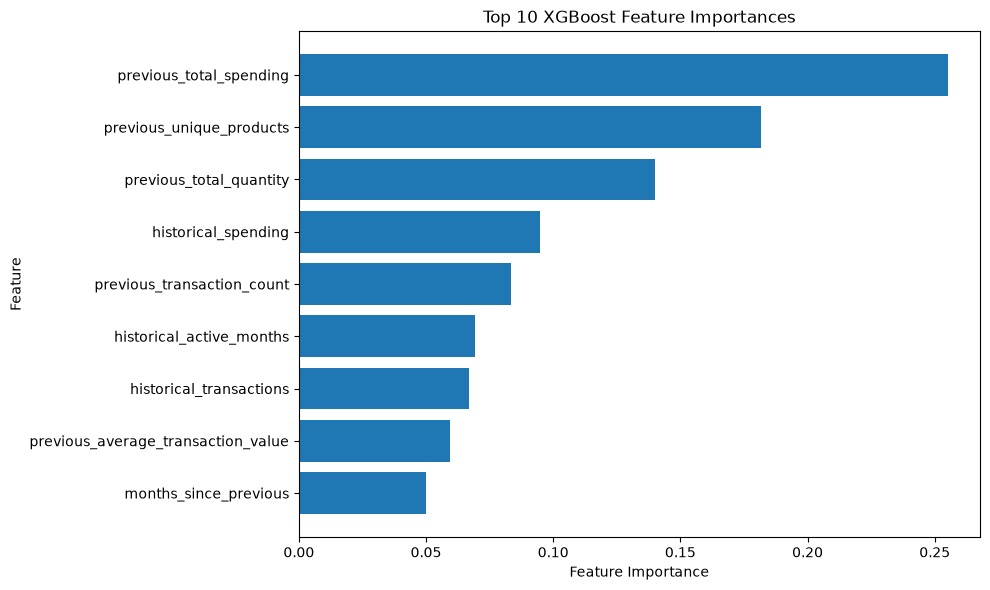

In [68]:
# Create output directory
os.makedirs("../outputs/plots/04_modeling", exist_ok=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb_features["feature"][::-1],
    top_xgb_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/plots/04_modeling/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The XGBoost feature importance analysis shows that recent customer behavior was highly influential in the model's predictions.

The most important features were `previous_total_spending` (25.5%), `previous_unique_products` (18.1%), and `previous_total_quantity` (14.0%). Together, these features accounted for approximately 57.5% of the total feature importance.

Historical features also contributed to the model, while `months_since_previous` had the lowest importance (5.0%) among the selected features.

Overall, the results support the use of behavior-aware features for detecting customer behavior shifts.


### Feature Importance Interpretation

The XGBoost feature importance analysis shows that recent behavioral information plays a major role in detecting customer behavior shifts.

The three most important features are `previous_total_spending`, `previous_unique_products`, and `previous_total_quantity`, which together account for approximately **57.6%** of the total feature importance.

This indicates that recent customer activity provides substantial predictive information beyond long-term historical customer characteristics.

However, feature importance reflects the model's reliance on a feature for prediction and should not be interpreted as causal importance.

## Final Model Selection

Based on the validation results, the candidate models are compared using F1-score, ROC-AUC, and PR-AUC.

The model with the strongest overall validation performance will be selected as the final model for the remaining analysis and deployment steps.


In [69]:
# Final validation model comparison

final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Behavior-Aware Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Threshold": [
        0.20,
        0.30,
        0.45,
        0.30
    ],

    "Precision": [
        0.188746,
        0.393548,
        0.339012,
        0.398453
    ],

    "Recall": [
        0.453521,
        0.515493,
        0.560563,
        0.580282
    ],

    "F1": [
        0.266556,
        0.446341,
        0.422505,
        0.472477
    ],

    "ROC-AUC": [
        0.576253,
        0.779406,
        0.779800,
        0.802158
    ],

    "PR-AUC": [
        0.180441,
        0.434740,
        0.414000,
        0.456175
    ]
})

final_model_comparison

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.20,0.188746,0.453521,0.266556,0.576253,0.180441
1,Behavior-Aware Logistic Regression,0.30,0.393548,0.515493,0.446341,0.779406,0.434740
2,Random Forest,0.45,0.339012,0.560563,0.422505,0.779800,0.414000
3,XGBoost,0.30,0.398453,0.580282,0.472477,0.802158,0.456175


### Final Model Selection

Based on the validation results, **XGBoost** was selected as the final model.

It achieved the highest F1-score (0.4725) and ROC-AUC (0.8022), while also providing the highest recall (0.5803) among the evaluated models.

A classification threshold of **0.30** was selected based on the highest validation F1-score. This threshold provides a better balance between precision and recall for detecting behavior shifts.


In [70]:
# Select XGBoost as the final model

final_model = xgb_model
final_threshold = best_xgb_threshold

print("Final model: XGBoost")
print(f"Final classification threshold: {final_threshold:.2f}")

Final model: XGBoost
Final classification threshold: 0.30


In [71]:
# Select XGBoost as the final model

final_model = xgb_model
final_threshold = best_xgb_threshold

print("Final model: XGBoost")
print(f"Final classification threshold: {final_threshold:.2f}")

Final model: XGBoost
Final classification threshold: 0.30


## Final Test Evaluation

The selected XGBoost model is evaluated on the held-out test set using the classification threshold selected from the validation set.

The test set was not used during model selection or threshold tuning, providing an unbiased estimate of the final model's performance on unseen data.


In [72]:
# Generate final XGBoost test predictions using the selected threshold

y_test_pred_final = (
    y_test_proba_xgb >= final_threshold
).astype(int)

print("Final test predictions generated.")
print("Predictions shape:", y_test_pred_final.shape)
print("Positive predictions:", y_test_pred_final.sum())
print("Total test observations:", len(y_test_pred_final))

Final test predictions generated.
Predictions shape: (4266,)
Positive predictions: 816
Total test observations: 4266


In [73]:
# Calculate final XGBoost test metrics

final_test_precision = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_test_recall = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_test_f1 = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

final_test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_xgb
)

final_test_pr_auc = average_precision_score(
    y_test,
    y_test_proba_xgb
)

print("Final XGBoost Test Metrics:")
print(f"Precision: {final_test_precision:.4f}")
print(f"Recall:    {final_test_recall:.4f}")
print(f"F1:        {final_test_f1:.4f}")
print(f"ROC-AUC:   {final_test_roc_auc:.4f}")
print(f"PR-AUC:    {final_test_pr_auc:.4f}")

Final XGBoost Test Metrics:
Precision: 0.4681
Recall:    0.4805
F1:        0.4742
ROC-AUC:   0.7746
PR-AUC:    0.4790


### Final XGBoost Confusion Matrix

The confusion matrix shows how the final XGBoost model classified behavior-shift and no-shift cases on the unseen test set using the selected threshold of 0.30.


In [74]:
# Final XGBoost confusion matrix

final_test_cm = confusion_matrix(
    y_test,
    y_test_pred_final
)

print("Final XGBoost Test Confusion Matrix:")
print(final_test_cm)

Final XGBoost Test Confusion Matrix:
[[3037  434]
 [ 413  382]]


In [75]:
# Final XGBoost classification report

final_test_report = classification_report(
    y_test,
    y_test_pred_final,
    target_names=["No Shift", "Behavior Shift"],
    zero_division=0
)

print("Final XGBoost Test Classification Report:")
print(final_test_report)

Final XGBoost Test Classification Report:
                precision    recall  f1-score   support

      No Shift       0.88      0.87      0.88      3471
Behavior Shift       0.47      0.48      0.47       795

      accuracy                           0.80      4266
     macro avg       0.67      0.68      0.68      4266
  weighted avg       0.80      0.80      0.80      4266



## Final Model Interpretation

The final XGBoost model achieved the strongest validation performance among the evaluated models, with an F1-score of 0.4725 and ROC-AUC of 0.8022. A classification threshold of 0.30 was selected based on the highest validation F1-score.

On the unseen test set, the final model achieved an F1-score of 0.4742, precision of 0.4681, recall of 0.4805, ROC-AUC of 0.7746, and PR-AUC of 0.4790.

These results indicate that the behavior-aware approach provides meaningful predictive information for detecting customer behavior shifts, although the model still misses a substantial number of actual shifts. Therefore, the model should be considered a useful detection tool rather than a definitive predictor of behavior change.


In [76]:
# Compare baseline and final XGBoost performance on the test set

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Final XGBoost"
    ],
    
    "Precision": [
        0.1887,
        final_test_precision
    ],
    
    "Recall": [
        0.4535,
        final_test_recall
    ],
    
    "F1": [
        0.2666,
        final_test_f1
    ],
    
    "ROC-AUC": [
        0.5763,
        final_test_roc_auc
    ],
    
    "PR-AUC": [
        0.1804,
        final_test_pr_auc
    ]
})

final_comparison

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline Logistic Regression,0.188700,0.453500,0.26660,0.576300,0.180400
1,Final XGBoost,0.468137,0.480503,0.47424,0.774632,0.478967


In [77]:
# Final validation comparison of all evaluated models

final_validation_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Behavior-Aware Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Threshold": [
        0.20,
        0.30,
        0.45,
        0.30
    ],

    "Precision": [
        0.188746,
        0.393548,
        0.339012,
        0.398453
    ],

    "Recall": [
        0.453521,
        0.515493,
        0.560563,
        0.580282
    ],

    "F1": [
        0.266556,
        0.446341,
        0.422505,
        0.472477
    ],

    "ROC-AUC": [
        0.576253,
        0.779406,
        0.779800,
        0.802158
    ],

    "PR-AUC": [
        0.180441,
        0.434740,
        0.414000,
        0.456175
    ]
})

final_validation_comparison

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline,0.20,0.188746,0.453521,0.266556,0.576253,0.180441
1,Behavior-Aware Logistic Regression,0.30,0.393548,0.515493,0.446341,0.779406,0.434740
2,Random Forest,0.45,0.339012,0.560563,0.422505,0.779800,0.414000
3,XGBoost,0.30,0.398453,0.580282,0.472477,0.802158,0.456175


### Model Comparison Interpretation

XGBoost achieved the strongest overall validation performance among the evaluated models, with the highest F1-score (0.4725), recall (0.5803), ROC-AUC (0.8022), and PR-AUC (0.4562).

The behavior-aware models substantially outperformed the baseline, indicating that incorporating recent customer activity provides useful information for detecting behavior shifts.

Based on these validation results, XGBoost was selected as the final model with a classification threshold of 0.30.


In [80]:
output_dir = Path("../outputs/plots/04_modeling")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory ready: {output_dir}")

Output directory ready: ..\outputs\plots\04_modeling


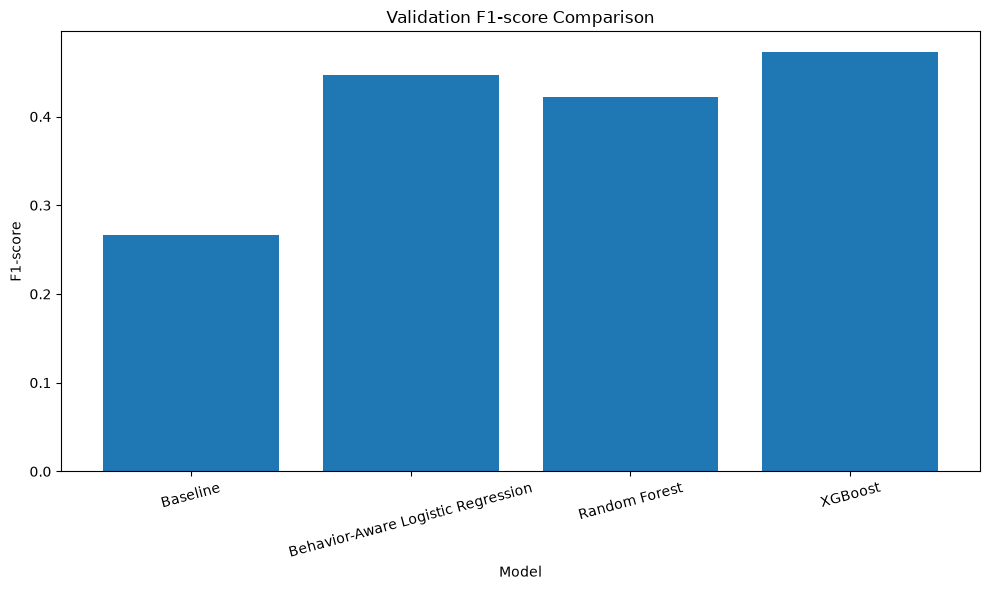

In [81]:
# Plot validation F1-score comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_validation_comparison["Model"],
    final_validation_comparison["F1"]
)

plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Validation F1-score Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    output_dir / "model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()